In [3]:
import pandas as pd

df = pd.read_csv("C:\\Users\\sumam\\OneDrive\\Documents\\Stock_market_Predictor\\Datasets\\random_stock_market_dataset.csv")
print(df.head())
df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']


         Date    Open    High     Low   Close  Volume
0  2024-01-01  296.45  307.31  293.96  303.72   93133
1  2024-01-02  190.11  193.10  187.21  191.40   64993
2  2024-01-03  197.41  208.64  193.37  205.89   70326
3  2024-01-04  253.13  262.67  248.67  258.95   17358
4  2024-01-05  241.35  253.09  238.99  252.20   20847


MAE: 1.12197934503403
MSE: 1.724006536901869
R2 Score: 0.9998330113337942


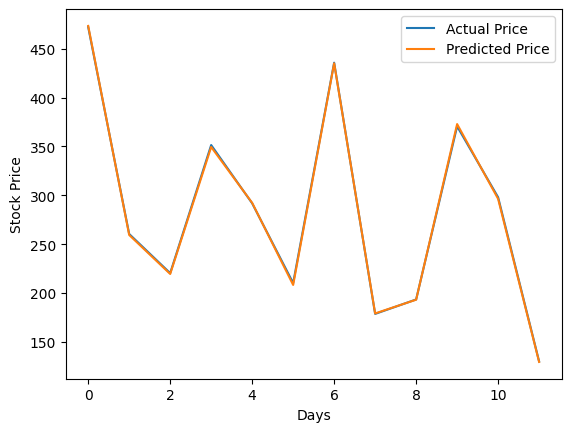

In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
split = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split]
X_test = X_scaled[split:]

y_train = y[:split]
y_test = y[split:]
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()